- Word Embedding yaparken 2 model kullanacağız bu uygulamada:
    - Word2Vec (Google)
    - FastText (Facebook)

In [ ]:
# Kütüphanelerimizi import edelim
from gensim.models import Word2Vec, FastText  # gensim kütüphanesinden Word2Vec ve FastText modellerini import ediyoruz
from gensim.utils import simple_preprocess # Metinleri basitçe ön işleme tabi tutmak için kullanılır
from sklearn.decomposition import PCA  # PCA (Principal Component Analysis) kütüphanesini import ediyoruz. Elde ettiğimiz vektörlerin boyutunu düşürmek için kullanacağız. Bildiğimiz temel bileşen analizi.
import matplotlib.pyplot as plt  # Görselleştirme için kullanacağız

In [4]:
# Örnek veri seti oluşturalım

sentences = [
    "Kedi çok tatlı bir hayvandır.",
    "Köpekler evcil hayvanlardır.",
    "Kediler genellikle bağımsızdır.",
    "Köpekler sadık ve dost canlısıdır.",
    "Hayvanlar insanlar için iyi arkadaşlardır."
]

In [5]:
# Şimdi cümleleri tokenize edelim (cümleleri kelimelere bölelim)
# Gensim'in simple_preprocess fonksiyonu, metinleri küçük harfe çevirir, noktalama işaretlerini kaldırır ve kelimelere böler.

tokenized_sentences = [simple_preprocess(sentence)for sentence in sentences]
tokenized_sentences

[['kedi', 'çok', 'tatlı', 'bir', 'hayvandır'],
 ['köpekler', 'evcil', 'hayvanlardır'],
 ['kediler', 'genellikle', 'bağımsızdır'],
 ['köpekler', 'sadık', 've', 'dost', 'canlısıdır'],
 ['hayvanlar', 'insanlar', 'için', 'iyi', 'arkadaşlardır']]

In [6]:
# Modellerimizin tanımlanması

# Word2Vec
word2vec_model = Word2Vec(sentences=tokenized_sentences, vector_size=50, window=5, min_count=1, sg=0)
  # sentences: eğitim için kullanılacak cümleler
    # vector_size: kelime vektörlerinin boyutu (her kelime vectoor_size boyutunda bir vektörle temsil edilecek)
    # window: her kelimenin etrafında kaç kelimeye bakılacağını belirler. Örneğin, window=5 ise, her kelimenin önceki ve sonraki 5 kelimesi dikkate alınır.
    # min_count: kelimenin modelde yer alabilmesi için frekansının minimum sayısı (örneğin, min_count=1 ise, modelde en az 1 kez geçen kelimeler yer alır)
    # sg: 0 ise CBOW (Continuous Bag of Words) modelini, 1 ise Skip-gram modelini kullanır. 
        # CBOW, bir kelimenin etrafındaki kelimelerden o kelimeyi tahmin etmeye çalışırken, 
        # Skip-gram bir kelimenin etrafındaki kelimeleri tahmin etmeye çalışır. 
        # Aslında basitçe 0-> BoW, 1-> N-Gram gibi düşünebiliriz.

# FastText
fasttext_model = FastText(sentences=tokenized_sentences, vector_size=50, window=5, min_count=1, sg=0)

In [7]:
# Görselleştirme için bir fonksiyon tanımlayalım
def plot_word_embeddings(model, title):
    # Modelin oluşturduğu kelime vektörlerini alalım
    word_vectors = model.wv  # Her bir kelimenin vektör temsilini alacağız
    words = list(word_vectors.index_to_key) # Kelimeleri alıyoruz. sona [:1000] ekleyerek ilk 1000 kelimeyi alabiliri. Şu an veri setimiz çok küçük olduğu için gerek yok.
    vectors = [word_vectors[word] for word in words]

    # PCA ile boyut indirgeyeceğiz çünkü normalde kelime vektörleri 50 boyutlu olarak ayarladık. Bunu 3 boyuta (x, y, z) indirgememiz gerekiyor ki görselleştirebilelim.
    pca = PCA(n_components=3) 
    reduced_vectors = pca.fit_transform(vectors)

    # 3D görselleştirme
    fig = plt.figure(figsize=(12,8))
    ax = fig.add_subplot(111, projection='3d') # 111 -> 1 satır, 1 sütun, 1. grafik

    # Vektörleri çiziyoruz. Tüm kelimelerin x,y,z koordinatları
    ax.scatter(reduced_vectors[:,0], reduced_vectors[:,1], reduced_vectors[:,2]) # x, y, z eksenleri 1. boyut, 2. boyut, 3. boyut

    # Noktalara etiket ekliyoruz ki hangi nokta hangi kelimeye ait bilelim. Her bir kelimenin x,y,z koordinatlarına kelime etiketini ekliyoruz
    for i, word in enumerate(words):
        ax.text(reduced_vectors[i,0], reduced_vectors[i,1], reduced_vectors[i,2], word, size=12)
    
    ax.set_title(title)
    ax.set_xlabel('Component 1 - X Axis')
    ax.set_ylabel('Component 2 - Y Axis')
    ax.set_zlabel('Component 3 - Z Axis')
    plt.show()


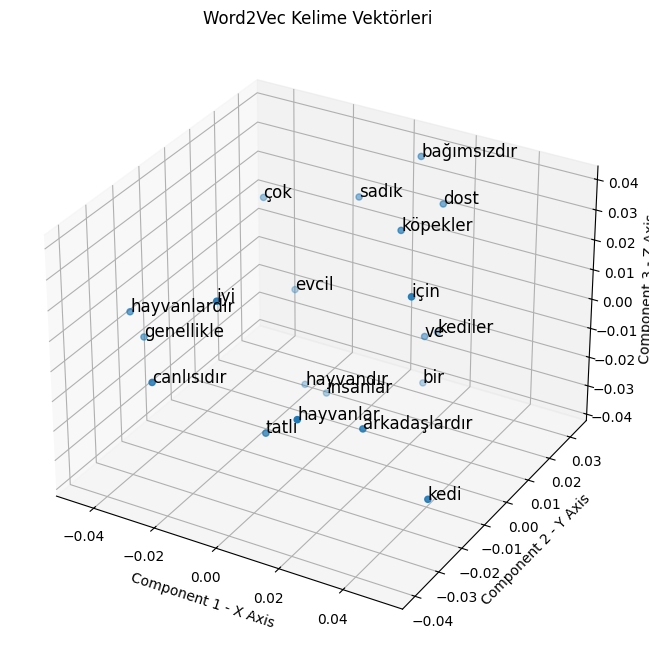

'\n\nUzamsal İlişkiler:\n- 3 boyutlu uzayda her kelime bir nokta olarak temsil edilmiştir\n- Birbirine anlamca yakın kelimeler uzayda da birbirine yakın konumlanmıştır\n- Örneğin "kedi" ve "kediler" kelimeleri birbirine yakın konumlanmıştır\n\nAnlamsal Gruplamalar:\n- Hayvan terimleri ("kedi", "köpekler", "hayvanlar") benzer bölgelerde kümelenmiştir\n- Sıfatlar ("tatlı", "sadık", "evcil") kendi aralarında gruplanma eğilimindedir\n\n'

In [ ]:
# Fonksiyonu kullanarak Word2Vec modelini görselleştirelim

plot_word_embeddings(word2vec_model, "Word2Vec Kelime Vektörleri")

"""
YORUMLAMA KISMI ÇOK SAĞLIKLI DEĞİL ÇÜNKÜ VERİ SETİMİZ ÇOK KÜÇÜK AMA TEMEL FİKİR ANLAŞILIYOR.

Uzamsal İlişkiler:
- 3 boyutlu uzayda her kelime bir nokta olarak temsil edilmiştir
- Birbirine anlamca yakın kelimeler uzayda da birbirine yakın konumlanmıştır
- Örneğin "kedi" ve "kediler" kelimeleri birbirine yakın konumlanmıştır

Anlamsal Gruplamalar:
- Hayvan terimleri ("kedi", "köpekler", "hayvanlar") benzer bölgelerde kümelenmiştir
- Sıfatlar ("tatlı", "sadık", "evcil") kendi aralarında gruplanma eğilimindedir

"""

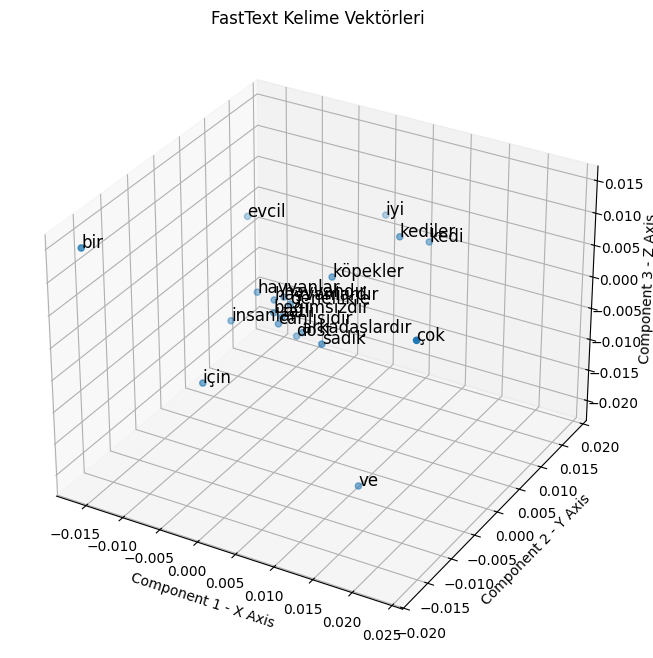

'\n1. Word2Vec ile Karşılaştırma\n- FastText modelinin ürettiği vektör uzayı Word2Vec\'e göre daha kompakt görünüyor\n- Değer aralıkları Word2Vec\'te (-0.04, 0.04) iken, FastText\'te (-0.020, 0.020) arasında\n\n2. Anlamsal Gruplamalar\n- Hayvan Terimleri: "kedi", "köpekler", "hayvanlar" yakın konumlanmış\n- İlişkisel Kelimeler: "için", "ve", "bir" gibi bağlaç/edat kelimeleri ayrı bir bölgede gruplanmış\n- Sıfatlar: "iyi", "evcil", "sadık" benzer bölgelerde kümelenmiş\n\n3. FastText\'in Avantajları\n- Alt kelime (subword) bilgisini kullandığı için benzer yapıdaki kelimeler daha tutarlı gruplanmış\n    - Örneğin: "hayvanlar", "hayvandır" kelimeleri ortak kök nedeniyle yakın konumlanmış\n\n4. Model Karakteristikleri\n- Kelimelerin dağılımı daha düzenli ve dengeli\n- Vektör uzayında daha az dağınık bir yapı görülüyor\n- Anlamsal ilişkiler daha net görülebiliyor\n'

In [10]:
# Fonksiyonu kullanarak FastText modelini görselleştirelim


plot_word_embeddings(fasttext_model, "FastText Kelime Vektörleri")

"""
1. Word2Vec ile Karşılaştırma
- FastText modelinin ürettiği vektör uzayı Word2Vec'e göre daha kompakt görünüyor
- Değer aralıkları Word2Vec'te (-0.04, 0.04) iken, FastText'te (-0.020, 0.020) arasında

2. Anlamsal Gruplamalar
- Hayvan Terimleri: "kedi", "köpekler", "hayvanlar" yakın konumlanmış
- İlişkisel Kelimeler: "için", "ve", "bir" gibi bağlaç/edat kelimeleri ayrı bir bölgede gruplanmış
- Sıfatlar: "iyi", "evcil", "sadık" benzer bölgelerde kümelenmiş

3. FastText'in Avantajları
- Alt kelime (subword) bilgisini kullandığı için benzer yapıdaki kelimeler daha tutarlı gruplanmış
    - Örneğin: "hayvanlar", "hayvandır" kelimeleri ortak kök nedeniyle yakın konumlanmış

4. Model Karakteristikleri
- Kelimelerin dağılımı daha düzenli ve dengeli
- Vektör uzayında daha az dağınık bir yapı görülüyor
- Anlamsal ilişkiler daha net görülebiliyor
"""